In [25]:
import os
import numpy as np
import scipy.io as sio
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from skimage.segmentation import slic
from skimage.morphology import opening, closing, disk
from skimage.measure import label, regionprops
from skimage.color import label2rgb
import matplotlib.pyplot as plt
import cv2

In [4]:
DATASET_DIR = 'Dataset'
SUBFOLDERS = ['DNCube', 'MMCube', 'OtherCube']
OUTPUT_DIR = 'OutputMasks'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [5]:
def load_all_hsi(dataset_dir, subfolders):
    hsi_list, file_list = [], []
    for folder in subfolders:
        folder_path = os.path.join(dataset_dir, folder)
        for file in os.listdir(folder_path):
            if file.endswith('.mat'):
                filepath = os.path.join(folder_path, file)
                mat = sio.loadmat(filepath)
                for key in mat:
                    if isinstance(mat[key], np.ndarray) and mat[key].ndim == 3:
                        hsi_list.append(mat[key])
                        file_list.append(file)
                        break
    return hsi_list, file_list

In [6]:
def normalize_hsi_cube(hsi):
    """Normalize each band individually to [0, 1] range."""
    hsi_norm = np.zeros_like(hsi)
    for i in range(hsi.shape[2]):
        band = hsi[:, :, i]
        band_min, band_max = np.min(band), np.max(band)
        hsi_norm[:, :, i] = (band - band_min) / (band_max - band_min + 1e-8)
    return hsi_norm

In [7]:
def apply_pca(hsi_cube, n_components=3):
    h, w, d = hsi_cube.shape
    reshaped = hsi_cube.reshape(-1, d)
    pca = PCA(n_components=n_components)
    pca_data = pca.fit_transform(reshaped)
    return pca_data.reshape(h, w, n_components)

In [8]:
def generate_mask(pca_image, hsi_cube, n_clusters=2):
    # Apply SLIC superpixels
    segments = slic(pca_image, n_segments=200, compactness=10, start_label=0)
    h, w = segments.shape
    superpixel_labels = np.unique(segments)

    # Compute mean spectral signature of each superpixel
    signatures = []
    for label_val in superpixel_labels:
        mask = segments == label_val
        spectra = hsi_cube[mask]
        mean_spectrum = spectra.mean(axis=0)
        signatures.append(mean_spectrum)
    signatures = np.array(signatures)

    # KMeans clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(signatures)

    # Convert clustered superpixels to pixel-wise mask
    mask = np.zeros((h, w), dtype=np.uint8)
    for i, label_val in enumerate(superpixel_labels):
        mask[segments == label_val] = cluster_labels[i]

    # Choose lesion cluster as the smaller area
    if np.sum(mask == 1) < np.sum(mask == 0):
        lesion_mask = (mask == 1).astype(np.uint8)
    else:
        lesion_mask = (mask == 0).astype(np.uint8)

    # Morphological filtering
    lesion_mask = opening(lesion_mask, disk(3))
    lesion_mask = closing(lesion_mask, disk(5))

    return lesion_mask

In [9]:
def extract_bounding_box(binary_mask):
    props = regionprops(label(binary_mask))
    if not props:
        return None
    largest_region = max(props, key=lambda x: x.area)
    return largest_region.bbox  # (min_row, min_col, max_row, max_col)

In [10]:
def visualize_and_save(image_rgb, mask, bbox, filename):
    output = image_rgb.copy()
    if bbox:
        minr, minc, maxr, maxc = bbox
        output = cv2.rectangle(output, (minc, minr), (maxc, maxr), (255, 0, 0), 2)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(image_rgb / 255.0)
    ax[0].set_title("PCA RGB Image")
    ax[1].imshow(mask, cmap='gray')
    ax[1].set_title("Predicted Mask")
    ax[2].imshow(output / 255.0)
    ax[2].set_title("Bounding Box")
    for a in ax:
        a.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, filename.replace('.mat', '_output.png')))
    plt.close()

In [11]:
def refine_mask(mask):
    """Keeps only the central, medium-sized blob assuming lesion is not background"""
    labeled = label(mask)
    regions = regionprops(labeled)

    if not regions:
        return mask

    # Select region closest to center
    h, w = mask.shape
    center = np.array([h / 2, w / 2])

    min_dist = float('inf')
    selected_region = None
    for r in regions:
        centroid = np.array(r.centroid)
        dist = np.linalg.norm(center - centroid)
        if dist < min_dist:
            min_dist = dist
            selected_region = r

    refined_mask = np.zeros_like(mask)
    if selected_region:
        refined_mask[labeled == selected_region.label] = 1

    return refined_mask

In [12]:
def apply_elliptical_roi(shape, scale=0.9):
    """Creates an elliptical mask for the central region of the HSI image."""
    h, w = shape[:2]
    y, x = np.ogrid[:h, :w]
    cy, cx = h // 2, w // 2
    ry, rx = h * scale / 2, w * scale / 2
    roi = ((y - cy) ** 2 / ry ** 2 + (x - cx) ** 2 / rx ** 2) <= 1
    return roi.astype(np.uint8)

In [13]:
# hsi_images, filenames = load_all_hsi(DATASET_DIR, SUBFOLDERS)
# print(f"Loaded {len(hsi_images)} HSI images.")

# for hsi_cube, fname in zip(hsi_images, filenames):
#     hsi_cube = np.nan_to_num(hsi_cube)
#     hsi_cube = normalize_hsi_cube(hsi_cube)
#     pca_rgb = apply_pca(hsi_cube)
#     # Generate mask from clustering
#     mask = generate_mask(pca_rgb, hsi_cube)
#     # Create elliptical ROI
#     roi = apply_elliptical_roi(mask.shape)
#     # Combine: restrict mask to center ROI
#     mask = mask * roi
#     # Refine: pick only central most likely lesion blob
#     mask = refine_mask(mask)
#     bbox = extract_bounding_box(mask)

#     # Normalize for visualization
#     vis_rgb = ((pca_rgb - pca_rgb.min()) / (pca_rgb.max() - pca_rgb.min()) * 255).astype(np.uint8)
#     visualize_and_save(vis_rgb, mask, bbox, fname)

# print("All masks and visualizations saved.")

In [15]:
from PIL import Image

MASK_SAVE_DIR = 'TrainData/masks'
IMAGE_SAVE_DIR = 'TrainData/images'
os.makedirs(MASK_SAVE_DIR, exist_ok=True)
os.makedirs(IMAGE_SAVE_DIR, exist_ok=True)

hsi_images, filenames = load_all_hsi(DATASET_DIR, SUBFOLDERS)
print(f"Loaded {len(hsi_images)} HSI images.")

for hsi_cube, fname in zip(hsi_images, filenames):
    hsi_cube = np.nan_to_num(hsi_cube)
    hsi_cube = normalize_hsi_cube(hsi_cube)
    pca_rgb = apply_pca(hsi_cube)
    mask = generate_mask(pca_rgb, hsi_cube)
    roi = apply_elliptical_roi(mask.shape)
    mask = mask * roi
    mask = refine_mask(mask)

    vis_rgb = ((pca_rgb - pca_rgb.min()) / (pca_rgb.max() - pca_rgb.min()) * 255).astype(np.uint8)

    image_name = fname.replace('.mat', '.png')
    Image.fromarray(vis_rgb).save(os.path.join(IMAGE_SAVE_DIR, image_name))
    Image.fromarray((mask * 255).astype(np.uint8)).save(os.path.join(MASK_SAVE_DIR, image_name))  # binary mask


Loaded 348 HSI images.


In [16]:
MASK_SAVE_DIR = 'TrainData/masks'
IMAGE_SAVE_DIR = 'TrainData/images'
os.makedirs(MASK_SAVE_DIR, exist_ok=True)
os.makedirs(IMAGE_SAVE_DIR, exist_ok=True)

In [22]:
import os

print("Images:", len(os.listdir(IMAGE_SAVE_DIR)))
print("Masks:", len(os.listdir(MASK_SAVE_DIR)))


Images: 267
Masks: 267


In [36]:
import os
import glob
from PIL import Image
from torch.utils.data import Dataset
import torchvision.transforms as T

class HSIImageDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_paths = sorted(glob.glob(os.path.join(image_dir, "*.png")))
        self.mask_paths = sorted(glob.glob(os.path.join(mask_dir, "*.png")))
        self.transform = transform

        assert len(self.image_paths) == len(self.mask_paths), "Mismatch between images and masks"

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")  # Grayscale

        image_np = np.array(image)
        mask_np = np.array(mask)

        if self.transform:
            transformed = self.transform(image=image_np, mask=mask_np)
            image_tensor = transformed["image"]
            mask_tensor = transformed["mask"]
        else:
            image_tensor = T.ToTensor()(image)
            mask_tensor = T.ToTensor()(mask).squeeze(0)

        return {
            "pixel_values": image_tensor.float(),
            "labels": mask_tensor.long()   # 👈 FIXED HERE
        }

    def __len__(self):
        return len(self.image_paths)


In [ ]:
# dataset = HSIImageDataset(IMAGE_SAVE_DIR, MASK_SAVE_DIR, transform=transform)
# print("Dataset size:", len(dataset))

Dataset size: 267


In [38]:
from transformers import SegformerFeatureExtractor, SegformerForSemanticSegmentation

feature_extractor = SegformerFeatureExtractor(do_reduce_labels=True, size=512, resample=2)
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512",
    num_labels=2,  # background and lesion
    ignore_mismatched_sizes=True
)


c:\Users\abhin\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers\models\segformer\feature_extraction_segformer.py:30: FutureWarning: The class SegformerFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use SegformerImageProcessor instead.
  warnings.warn(
Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([2]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([2, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [39]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=0.0, std=1.0, max_pixel_value=1.0),
    ToTensorV2()
])


In [40]:
sample = dataset[0]
print(sample["pixel_values"].dtype)  # torch.float32
print(sample["labels"].dtype)        # torch.int64 (aka Long)


torch.float32
torch.int64


In [41]:
from torch.utils.data import DataLoader
from transformers import TrainingArguments, Trainer
import torch
from sklearn.model_selection import train_test_split

dataset = HSIImageDataset(IMAGE_SAVE_DIR, MASK_SAVE_DIR, transform=transform)
train_loader = DataLoader(dataset, batch_size=4, shuffle=True)

args = TrainingArguments(
    output_dir="./segformer_results",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=30,
    logging_dir='./logs'
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    iou = np.logical_and(preds, labels).sum() / np.logical_or(preds, labels).sum()
    dice = 2 * np.logical_and(preds, labels).sum() / (preds.sum() + labels.sum())
    return {"IoU": iou, "Dice": dice}


train_indices, val_indices = train_test_split(np.arange(len(dataset)), test_size=0.2, random_state=42)
train_dataset = torch.utils.data.Subset(dataset, train_indices)
val_dataset = torch.utils.data.Subset(dataset, val_indices)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=feature_extractor,
    compute_metrics=compute_metrics
)
trainer.train()



C:\Users\abhin\AppData\Local\Temp\ipykernel_16032\2595492376.py:29: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.134600
1000,0.012800
1500,0.007000


TrainOutput(global_step=1620, training_loss=0.04808714382442427, metrics={'train_runtime': 101.6628, 'train_samples_per_second': 62.855, 'train_steps_per_second': 15.935, 'total_flos': 2.800090894565376e+16, 'train_loss': 0.04808714382442427, 'epoch': 30.0})

In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from transformers import SegformerFeatureExtractor, SegformerForSemanticSegmentation
from transformers import TrainingArguments, Trainer
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

c:\Users\abhin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MASK_SAVE_DIR = 'TrainData/masks'
IMAGE_SAVE_DIR = 'TrainData/images'
RESULTS_DIR = 'SegformerResults'
VISUALIZATION_DIR = 'Visualizations'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(VISUALIZATION_DIR, exist_ok=True)

In [3]:
class HSIImageDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None, feature_extractor=None):
        self.image_paths = sorted(glob.glob(os.path.join(image_dir, "*.png")))
        self.mask_paths = sorted(glob.glob(os.path.join(mask_dir, "*.png")))
        self.transform = transform
        self.feature_extractor = feature_extractor

        assert len(self.image_paths) == len(self.mask_paths), f"Mismatch: {len(self.image_paths)} images vs {len(self.mask_paths)} masks"
        print(f"Dataset initialized with {len(self.image_paths)} samples")

    def __getitem__(self, idx):
        # Load image and mask
        image = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")  # Grayscale

        image_np = np.array(image)
        mask_np = np.array(mask)

        # Binarize mask (in case it's not perfectly binary)
        mask_np = (mask_np > 128).astype(np.uint8)

        if self.transform:
            transformed = self.transform(image=image_np, mask=mask_np)
            image_tensor = transformed["image"]
            mask_tensor = transformed["mask"]
        else:
            image_tensor = T.ToTensor()(image)
            mask_tensor = torch.from_numpy(mask_np).long()

        return {
            "pixel_values": image_tensor.float(),
            "labels": mask_tensor.long()
        }

    def __len__(self):
        return len(self.image_paths)

In [4]:
def compute_comprehensive_metrics(eval_pred):
    """Comprehensive evaluation metrics for semantic segmentation."""
    predictions, labels = eval_pred
    
    # Handle the predictions - they come as logits
    if len(predictions.shape) == 4:  # [batch, num_classes, height, width]
        predictions = np.argmax(predictions, axis=1)  # [batch, height, width]
    
    # Flatten for metrics computation
    predictions_flat = predictions.flatten()
    labels_flat = labels.flatten()
    
    # Basic metrics
    accuracy = accuracy_score(labels_flat, predictions_flat)
    
    # For binary segmentation (background=0, lesion=1)
    precision = precision_score(labels_flat, predictions_flat, average='binary', zero_division=0)
    recall = recall_score(labels_flat, predictions_flat, average='binary', zero_division=0)
    f1 = f1_score(labels_flat, predictions_flat, average='binary', zero_division=0)
    
    # IoU (Jaccard Index)
    iou = jaccard_score(labels_flat, predictions_flat, average='binary', zero_division=0)
    
    # Dice Score (F1 score is equivalent to Dice for binary classification)
    dice = f1
    
    # Specificity (True Negative Rate)
    tn = np.sum((labels_flat == 0) & (predictions_flat == 0))
    fp = np.sum((labels_flat == 0) & (predictions_flat == 1))
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # Sensitivity (same as recall)
    sensitivity = recall
    
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "iou": iou,
        "dice_score": dice,
        "specificity": specificity,
        "sensitivity": sensitivity
    }

In [12]:
MASK_SAVE_DIR = 'TrainData/masks'
IMAGE_SAVE_DIR = 'TrainData/images'
RESULTS_DIR = 'SegformerResults'
VISUALIZATION_DIR = 'Visualizations'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(VISUALIZATION_DIR, exist_ok=True)

class HSIImageDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None, feature_extractor=None):
        self.image_paths = sorted(glob.glob(os.path.join(image_dir, "*.png")))
        self.mask_paths = sorted(glob.glob(os.path.join(mask_dir, "*.png")))
        self.transform = transform
        self.feature_extractor = feature_extractor

        assert len(self.image_paths) == len(self.mask_paths), f"Mismatch: {len(self.image_paths)} images vs {len(self.mask_paths)} masks"
        print(f"Dataset initialized with {len(self.image_paths)} samples")

    def __getitem__(self, idx):
        # Load image and mask
        image = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")  # Grayscale

        image_np = np.array(image)
        mask_np = np.array(mask)

        # Binarize mask (in case it's not perfectly binary)
        mask_np = (mask_np > 128).astype(np.uint8)

        if self.transform:
            transformed = self.transform(image=image_np, mask=mask_np)
            image_tensor = transformed["image"]
            mask_tensor = transformed["mask"]
        else:
            image_tensor = T.ToTensor()(image)
            mask_tensor = torch.from_numpy(mask_np)

        # Ensure mask is the right type and shape
        if len(mask_tensor.shape) == 2:  # [H, W]
            mask_tensor = mask_tensor.long()
        elif len(mask_tensor.shape) == 3:  # [C, H, W] - squeeze if single channel
            if mask_tensor.shape[0] == 1:
                mask_tensor = mask_tensor.squeeze(0).long()
            else:
                mask_tensor = mask_tensor.long()

        return {
            "pixel_values": image_tensor.float(),
            "labels": mask_tensor
        }

    def __len__(self):
        return len(self.image_paths)

def compute_comprehensive_metrics(eval_pred):
    """Comprehensive evaluation metrics for semantic segmentation."""
    predictions, labels = eval_pred
    
    # Debug print to understand shapes
    print(f"Predictions shape: {predictions.shape}")
    print(f"Labels shape: {labels.shape}")
    
    # Handle the predictions - they come as logits
    if len(predictions.shape) == 4:  # [batch, num_classes, height, width]
        predictions = np.argmax(predictions, axis=1)  # [batch, height, width]
    elif len(predictions.shape) == 3 and predictions.shape[-1] == 2:  # [batch, height, width, num_classes]
        predictions = np.argmax(predictions, axis=-1)  # [batch, height, width]
    
    # Ensure labels and predictions have the same shape
    if predictions.shape != labels.shape:
        print(f"Shape mismatch - Predictions: {predictions.shape}, Labels: {labels.shape}")
        
        # Try to resize predictions to match labels
        from scipy.ndimage import zoom
        if len(predictions.shape) == 3 and len(labels.shape) == 3:
            # Calculate zoom factors for each dimension
            zoom_factors = [labels.shape[i] / predictions.shape[i] for i in range(3)]
            predictions = zoom(predictions, zoom_factors, order=0)  # Nearest neighbor for labels
            print(f"Resized predictions to: {predictions.shape}")
    
    # Flatten for metrics computation
    predictions_flat = predictions.flatten()
    labels_flat = labels.flatten()
    
    # Ensure same length after flattening
    min_length = min(len(predictions_flat), len(labels_flat))
    predictions_flat = predictions_flat[:min_length]
    labels_flat = labels_flat[:min_length]
    
    print(f"Final flattened shapes - Predictions: {len(predictions_flat)}, Labels: {len(labels_flat)}")
    
    # Basic metrics
    try:
        accuracy = accuracy_score(labels_flat, predictions_flat)
        
        # For binary segmentation (background=0, lesion=1)
        precision = precision_score(labels_flat, predictions_flat, average='binary', zero_division=0)
        recall = recall_score(labels_flat, predictions_flat, average='binary', zero_division=0)
        f1 = f1_score(labels_flat, predictions_flat, average='binary', zero_division=0)
        
        # IoU (Jaccard Index)
        iou = jaccard_score(labels_flat, predictions_flat, average='binary', zero_division=0)
        
        # Dice Score (F1 score is equivalent to Dice for binary classification)
        dice = f1
        
        # Specificity (True Negative Rate)
        tn = np.sum((labels_flat == 0) & (predictions_flat == 0))
        fp = np.sum((labels_flat == 0) & (predictions_flat == 1))
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        # Sensitivity (same as recall)
        sensitivity = recall
        
        return {
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "iou": iou,
            "dice_score": dice,
            "specificity": specificity,
            "sensitivity": sensitivity
        }
    except Exception as e:
        print(f"Error computing metrics: {e}")
        return {
            "accuracy": 0.0,
            "precision": 0.0,
            "recall": 0.0,
            "f1_score": 0.0,
            "iou": 0.0,
            "dice_score": 0.0,
            "specificity": 0.0,
            "sensitivity": 0.0
        }

def visualize_predictions(model, dataset, device, num_samples=8, save_path=None):
    """Visualize model predictions vs ground truth."""
    model.eval()
    
    # Randomly select samples
    indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)
    
    fig, axes = plt.subplots(3, len(indices), figsize=(3*len(indices), 9))
    if len(indices) == 1:
        axes = axes.reshape(-1, 1)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            sample = dataset[idx]
            image = sample["pixel_values"].unsqueeze(0).to(device)
            true_mask = sample["labels"].numpy()
            
            # Get prediction
            outputs = model(image)
            predictions = outputs.logits
            
            # Process prediction
            predicted_mask = torch.argmax(predictions.squeeze(), dim=0).cpu().numpy()
            
            # Convert image for visualization
            img_vis = sample["pixel_values"].permute(1, 2, 0).numpy()
            img_vis = (img_vis - img_vis.min()) / (img_vis.max() - img_vis.min())
            
            # Plot original image
            axes[0, i].imshow(img_vis)
            axes[0, i].set_title(f'Original Image {idx}')
            axes[0, i].axis('off')
            
            # Plot ground truth mask
            axes[1, i].imshow(true_mask, cmap='gray')
            axes[1, i].set_title('Ground Truth')
            axes[1, i].axis('off')
            
            # Plot predicted mask
            axes[2, i].imshow(predicted_mask, cmap='gray')
            axes[2, i].set_title('Prediction')
            axes[2, i].axis('off')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Visualization saved to {save_path}")
    plt.show()

In [22]:

def visualize_overlay_predictions(model, dataset, device, num_samples=4, save_path=None):
    """Visualize predictions as colored overlays on original images."""
    model.eval()
    
    indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)
    
    fig, axes = plt.subplots(2, len(indices), figsize=(4*len(indices), 8))
    if len(indices) == 1:
        axes = axes.reshape(-1, 1)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            sample = dataset[idx]
            image = sample["pixel_values"].unsqueeze(0).to(device)
            true_mask = sample["labels"].numpy()
            
            # Get prediction
            outputs = model(image)
            predictions = outputs.logits
            predicted_mask = torch.argmax(predictions.squeeze(), dim=0).cpu().numpy()
            
            # Print shapes for debugging
            print(f"Sample {i}:")
            print(f"  Image shape: {sample['pixel_values'].shape}")
            print(f"  True mask shape: {true_mask.shape}")
            print(f"  Predicted mask shape: {predicted_mask.shape}")
            
            # Convert image for visualization
            img_vis = sample["pixel_values"].permute(1, 2, 0).numpy()
            
            # Handle case where image has only 3 channels after PCA
            if img_vis.shape[2] == 3:
                # Normalize for RGB-like display
                img_vis = (img_vis - img_vis.min()) / (img_vis.max() - img_vis.min())
            else:
                # If more than 3 channels, take first 3 or create RGB
                if img_vis.shape[2] > 3:
                    img_vis = img_vis[:, :, :3]
                else:
                    # If less than 3, replicate channels
                    img_vis = np.repeat(img_vis, 3, axis=2)[:, :, :3]
                img_vis = (img_vis - img_vis.min()) / (img_vis.max() - img_vis.min())
            
            # Resize masks to match image dimensions if needed
            target_height, target_width = img_vis.shape[:2]
            
            if true_mask.shape != (target_height, target_width):
                print(f"  Resizing true_mask from {true_mask.shape} to ({target_height}, {target_width})")
                true_mask = cv2.resize(true_mask.astype(np.uint8), 
                                     (target_width, target_height), 
                                     interpolation=cv2.INTER_NEAREST).astype(bool)
            
            if predicted_mask.shape != (target_height, target_width):
                print(f"  Resizing predicted_mask from {predicted_mask.shape} to ({target_height}, {target_width})")
                predicted_mask = cv2.resize(predicted_mask.astype(np.uint8), 
                                          (target_width, target_height), 
                                          interpolation=cv2.INTER_NEAREST).astype(bool)
            
            # Create overlays
            gt_overlay = img_vis.copy()
            pred_overlay = img_vis.copy()
            
            # Ground truth overlay (green) - ensure boolean indexing works
            try:
                gt_overlay[true_mask == 1] = [0, 1, 0]
            except IndexError as e:
                print(f"Error with ground truth overlay: {e}")
                print(f"gt_overlay shape: {gt_overlay.shape}, true_mask shape: {true_mask.shape}")
                continue
            
            # Prediction overlay (red) - ensure boolean indexing works  
            try:
                pred_overlay[predicted_mask == 1] = [1, 0, 0]
            except IndexError as e:
                print(f"Error with prediction overlay: {e}")
                print(f"pred_overlay shape: {pred_overlay.shape}, predicted_mask shape: {predicted_mask.shape}")
                continue
            
            # Plot ground truth overlay
            axes[0, i].imshow(gt_overlay)
            axes[0, i].set_title(f'Ground Truth Overlay {idx}')
            axes[0, i].axis('off')
            
            # Plot prediction overlay
            axes[1, i].imshow(pred_overlay)
            axes[1, i].set_title('Prediction Overlay')
            axes[1, i].axis('off')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Overlay visualization saved to {save_path}")
    plt.show()

In [14]:
def plot_training_metrics(trainer, save_path=None):
    """Plot training and validation metrics over epochs."""
    
    # Extract metrics from trainer logs
    logs = trainer.state.log_history
    
    train_metrics = {}
    eval_metrics = {}
    
    for log in logs:
        if 'train_loss' in log:
            epoch = log.get('epoch', 0)
            if 'train_loss' not in train_metrics:
                train_metrics['train_loss'] = []
                train_metrics['epochs'] = []
            train_metrics['train_loss'].append(log['train_loss'])
            train_metrics['epochs'].append(epoch)
        
        if 'eval_loss' in log:
            epoch = log.get('epoch', 0)
            for key, value in log.items():
                if key.startswith('eval_'):
                    metric_name = key.replace('eval_', '')
                    if metric_name not in eval_metrics:
                        eval_metrics[metric_name] = []
                        if 'epochs' not in eval_metrics:
                            eval_metrics['epochs'] = []
                    eval_metrics[metric_name].append(value)
            if 'epochs' not in eval_metrics or len(eval_metrics['epochs']) < len(eval_metrics['loss']):
                eval_metrics['epochs'].append(epoch)
    
    # Create subplots
    num_metrics = len([k for k in eval_metrics.keys() if k != 'epochs'])
    fig, axes = plt.subplots(2, max(2, num_metrics//2), figsize=(15, 8))
    axes = axes.flatten()
    
    plot_idx = 0
    
    # Plot training and validation loss
    if 'train_loss' in train_metrics and 'loss' in eval_metrics:
        axes[plot_idx].plot(train_metrics['epochs'], train_metrics['train_loss'], 'b-', label='Train Loss')
        axes[plot_idx].plot(eval_metrics['epochs'], eval_metrics['loss'], 'r-', label='Val Loss')
        axes[plot_idx].set_title('Training and Validation Loss')
        axes[plot_idx].set_xlabel('Epoch')
        axes[plot_idx].set_ylabel('Loss')
        axes[plot_idx].legend()
        axes[plot_idx].grid(True)
        plot_idx += 1
    
    # Plot other metrics
    metric_names = ['accuracy', 'f1_score', 'iou', 'dice_score', 'precision', 'recall']
    
    for metric in metric_names:
        if metric in eval_metrics and plot_idx < len(axes):
            axes[plot_idx].plot(eval_metrics['epochs'], eval_metrics[metric], 'g-', marker='o')
            axes[plot_idx].set_title(f'Validation {metric.replace("_", " ").title()}')
            axes[plot_idx].set_xlabel('Epoch')
            axes[plot_idx].set_ylabel(metric.replace("_", " ").title())
            axes[plot_idx].grid(True)
            plot_idx += 1
    
    # Hide unused subplots
    for i in range(plot_idx, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Training metrics plot saved to {save_path}")
    plt.show()

In [19]:
def evaluate_model_comprehensive(model, dataset, device):
    """Comprehensive evaluation of the trained model."""
    model.eval()
    
    all_predictions = []
    all_labels = []
    
    dataloader = DataLoader(dataset, batch_size=4, shuffle=False)
    
    with torch.no_grad():
        for i, batch in enumerate(tqdm(dataloader, desc="Evaluating")):
            images = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)
            
            # Print shapes for debugging (only first batch)
            if i == 0:
                print(f"Input images shape: {images.shape}")
                print(f"Labels shape: {labels.shape}")
            
            outputs = model(images)
            
            # Print output shape for debugging (only first batch)
            if i == 0:
                print(f"Model outputs shape: {outputs.logits.shape}")
            
            # Get predictions
            predictions = torch.argmax(outputs.logits, dim=1)
            
            # Print prediction shape for debugging (only first batch)
            if i == 0:
                print(f"Predictions shape: {predictions.shape}")
                print(f"Predictions flattened length: {predictions.cpu().numpy().flatten().shape}")
                print(f"Labels flattened length: {labels.cpu().numpy().flatten().shape}")
            
            # Handle potential shape mismatches
            if predictions.shape != labels.shape:
                print(f"Warning: Shape mismatch - Predictions: {predictions.shape}, Labels: {labels.shape}")
                
                # If predictions have extra dimensions, reshape appropriately
                if len(predictions.shape) > len(labels.shape):
                    predictions = predictions.squeeze()
                elif len(predictions.shape) < len(labels.shape):
                    # If labels have extra dimensions, reshape labels
                    labels = labels.squeeze()
                
                # If still mismatched, try interpolation (for different spatial resolutions)
                if predictions.shape != labels.shape:
                    print("Attempting to resize predictions to match labels...")
                    predictions = torch.nn.functional.interpolate(
                        predictions.float().unsqueeze(1), 
                        size=labels.shape[-2:], 
                        mode='nearest'
                    ).squeeze(1).long()
            
            # Flatten and add to lists
            pred_flat = predictions.cpu().numpy().flatten()
            label_flat = labels.cpu().numpy().flatten()
            
            all_predictions.extend(pred_flat)
            all_labels.extend(label_flat)
    
    # Convert to numpy arrays
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    
    print(f"Final - Predictions shape: {all_predictions.shape}")
    print(f"Final - Labels shape: {all_labels.shape}")
    
    # Ensure both arrays have the same length
    if len(all_predictions) != len(all_labels):
        min_length = min(len(all_predictions), len(all_labels))
        all_predictions = all_predictions[:min_length]
        all_labels = all_labels[:min_length]
        print(f"Truncated to common length: {min_length}")
    
    # Compute metrics
    metrics = {
        'accuracy': accuracy_score(all_labels, all_predictions),
        'precision': precision_score(all_labels, all_predictions, average='binary', zero_division=0),
        'recall': recall_score(all_labels, all_predictions, average='binary', zero_division=0),
        'f1_score': f1_score(all_labels, all_predictions, average='binary', zero_division=0),
        'iou': jaccard_score(all_labels, all_predictions, average='binary', zero_division=0),
        'specificity': precision_score(all_labels, all_predictions, pos_label=0, average='binary', zero_division=0)
    }
    
    metrics['dice_score'] = metrics['f1_score']  # Dice is equivalent to F1 for binary
    metrics['sensitivity'] = metrics['recall']   # Sensitivity is recall
    
    return metrics

In [20]:
def custom_data_collator(batch):
    """Custom data collator to handle batching for segmentation."""
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels = torch.stack([item["labels"] for item in batch])
    
    return {
        "pixel_values": pixel_values,
        "labels": labels
    }

In [23]:
print("Starting SegFormer training with comprehensive evaluation...")

# Check if data exists
if not os.path.exists(IMAGE_SAVE_DIR) or not os.path.exists(MASK_SAVE_DIR):
    print("Error: Training data directories not found. Please run the HSI processing code first.")

print(f"Images: {len(os.listdir(IMAGE_SAVE_DIR))}")
print(f"Masks: {len(os.listdir(MASK_SAVE_DIR))}")

# Initialize feature extractor and model with updated API
try:
    # Try newer API first
    from transformers import SegformerImageProcessor
    feature_extractor = SegformerImageProcessor(do_reduce_labels=False, size=256, resample=2)
except ImportError:
    # Fall back to older API
    feature_extractor = SegformerFeatureExtractor(do_reduce_labels=False, size=256, resample=2)

model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512",  # Smaller model for faster training
    num_labels=2,  # background and lesion
    ignore_mismatched_sizes=True
)

# Set up transforms - simplified to avoid issues
transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.3),
    A.VerticalFlip(p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # ImageNet normalization
    ToTensorV2()
])

# Create dataset
dataset = HSIImageDataset(IMAGE_SAVE_DIR, MASK_SAVE_DIR, transform=transform, feature_extractor=feature_extractor)

# Test a single sample to check shapes
sample = dataset[0]
print(f"Sample image shape: {sample['pixel_values'].shape}")
print(f"Sample label shape: {sample['labels'].shape}")
print(f"Sample label unique values: {torch.unique(sample['labels'])}")

# Train-validation split
train_indices, val_indices = train_test_split(
    np.arange(len(dataset)), 
    test_size=0.2, 
    random_state=42,
    stratify=None  # Remove stratification for small datasets
)

train_dataset = torch.utils.data.Subset(dataset, train_indices)
val_dataset = torch.utils.data.Subset(dataset, val_indices)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Training arguments
args = TrainingArguments(
    output_dir=RESULTS_DIR,
    per_device_train_batch_size=2,  # Reduced for stability
    per_device_eval_batch_size=2,
    num_train_epochs=20,  # Reduced for testing
    eval_strategy="epoch",  # Updated parameter name
    save_strategy="epoch",
    logging_steps=5,
    learning_rate=5e-5,
    weight_decay=0.01,
    warmup_steps=50,
    logging_dir=os.path.join(RESULTS_DIR, 'logs'),
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_score",
    greater_is_better=True,
    report_to=[],  # Empty list instead of None
    save_total_limit=2,
    dataloader_pin_memory=False,  # Disable pin memory to avoid potential issues
)

# Initialize trainer
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_comprehensive_metrics,
    data_collator=custom_data_collator,  # Add custom data collator
)

# Train the model
print("Starting training...")
trainer.train()

# Save the final model
model.save_pretrained(os.path.join(RESULTS_DIR, "final_model"))
feature_extractor.save_pretrained(os.path.join(RESULTS_DIR, "final_model"))

# Comprehensive evaluation
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

Starting SegFormer training with comprehensive evaluation...
Images: 267
Masks: 267


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([2]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([2, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Dataset initialized with 267 samples
Sample image shape: torch.Size([3, 256, 256])
Sample label shape: torch.Size([256, 256])
Sample label unique values: tensor([0, 1])
Training samples: 213
Validation samples: 54
Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 Score,Iou,Dice Score,Specificity,Sensitivity
1,0.321400,0.245660,0.964302,0.615678,0.759977,0.680259,0.515449,0.680259,0.975049,0.759977
2,0.222300,0.115790,0.977213,0.871999,0.637545,0.736565,0.582986,0.736565,0.995078,0.637545
3,0.122000,0.088202,0.978039,0.898470,0.631896,0.741965,0.589781,0.741965,0.996244,0.631896
4,0.074600,0.078238,0.978008,0.815148,0.724079,0.766919,0.621954,0.766919,0.991364,0.724079
5,0.097400,0.074039,0.979690,0.892741,0.674586,0.768481,0.624011,0.768481,0.995737,0.674586
6,0.050500,0.065734,0.979915,0.852293,0.723417,0.782584,0.642824,0.782584,0.993406,0.723417
7,0.037000,0.061655,0.979320,0.837856,0.726770,0.778370,0.637156,0.778370,0.992603,0.726770
8,0.049800,0.061577,0.980353,0.868079,0.715551,0.784470,0.645372,0.784470,0.994281,0.715551
9,0.045600,0.057609,0.980986,0.873014,0.724916,0.792102,0.655769,0.792102,0.994454,0.724916
10,0.033800,0.056632,0.980243,0.841059,0.745477,0.790389,0.653424,0.790389,0.992590,0.745477


Predictions shape: (54, 2, 64, 64)
Labels shape: (54, 256, 256)
Shape mismatch - Predictions: (54, 64, 64), Labels: (54, 256, 256)
Resized predictions to: (54, 256, 256)
Final flattened shapes - Predictions: 3538944, Labels: 3538944
Predictions shape: (54, 2, 64, 64)
Labels shape: (54, 256, 256)
Shape mismatch - Predictions: (54, 64, 64), Labels: (54, 256, 256)
Resized predictions to: (54, 256, 256)
Final flattened shapes - Predictions: 3538944, Labels: 3538944
Predictions shape: (54, 2, 64, 64)
Labels shape: (54, 256, 256)
Shape mismatch - Predictions: (54, 64, 64), Labels: (54, 256, 256)
Resized predictions to: (54, 256, 256)
Final flattened shapes - Predictions: 3538944, Labels: 3538944
Predictions shape: (54, 2, 64, 64)
Labels shape: (54, 256, 256)
Shape mismatch - Predictions: (54, 64, 64), Labels: (54, 256, 256)
Resized predictions to: (54, 256, 256)
Final flattened shapes - Predictions: 3538944, Labels: 3538944
Predictions shape: (54, 2, 64, 64)
Labels shape: (54, 256, 256)
Shap

SegformerForSemanticSegmentation(
  (segformer): SegformerModel(
    (encoder): SegformerEncoder(
      (patch_embeddings): ModuleList(
        (0): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(3, 32, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (layer_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        )
        (1): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        )
        (2): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(64, 160, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
        )
        (3): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(160, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  


Performing comprehensive evaluation...


Evaluating:   7%|▋         | 1/14 [00:00<00:02,  6.30it/s]

Input images shape: torch.Size([4, 3, 256, 256])
Labels shape: torch.Size([4, 256, 256])
Model outputs shape: torch.Size([4, 2, 64, 64])
Predictions shape: torch.Size([4, 64, 64])
Predictions flattened length: (16384,)
Labels flattened length: (262144,)
Attempting to resize predictions to match labels...
Attempting to resize predictions to match labels...


Evaluating:  14%|█▍        | 2/14 [00:00<00:01,  6.67it/s]

Attempting to resize predictions to match labels...


...

Attempting to resize predictions to match labels...


Evaluating:  93%|█████████▎| 13/14 [00:01<00:00,  8.00it/s]

Attempting to resize predictions to match labels...


Evaluating: 100%|██████████| 14/14 [00:01<00:00,  8.02it/s]


Attempting to resize predictions to match labels...
Final - Predictions shape: (3538944,)
Final - Labels shape: (3538944,)

Final Validation Metrics:
Accuracy: 0.9803
Precision: 0.8368
Recall: 0.7513
F1 Score: 0.7917
Iou: 0.6553
Specificity: 0.9870
Dice Score: 0.7917
Sensitivity: 0.7513

Generating visualizations...
Training metrics plot saved to Visualizations\training_metrics.png


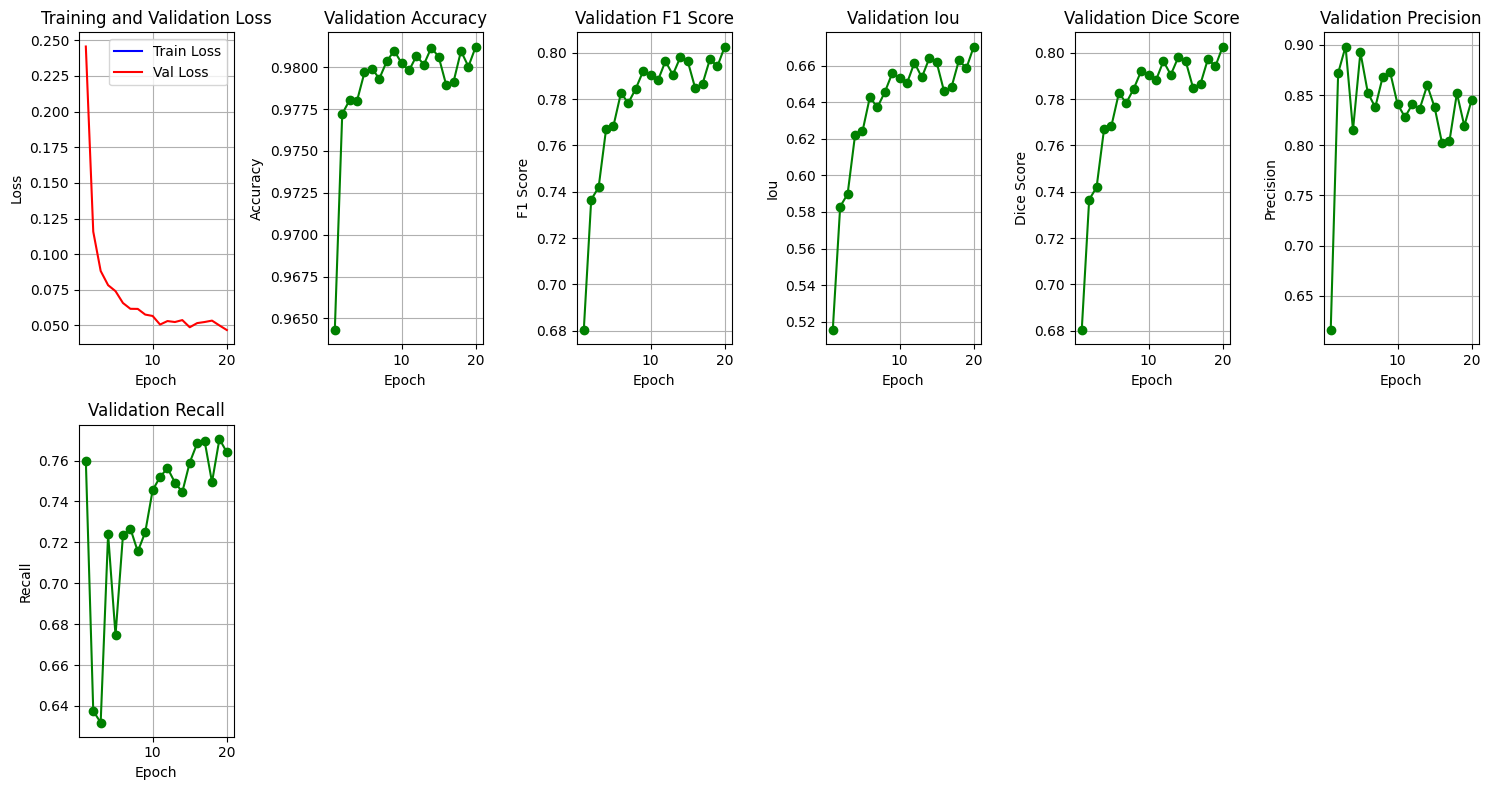

Visualization saved to Visualizations\predictions.png


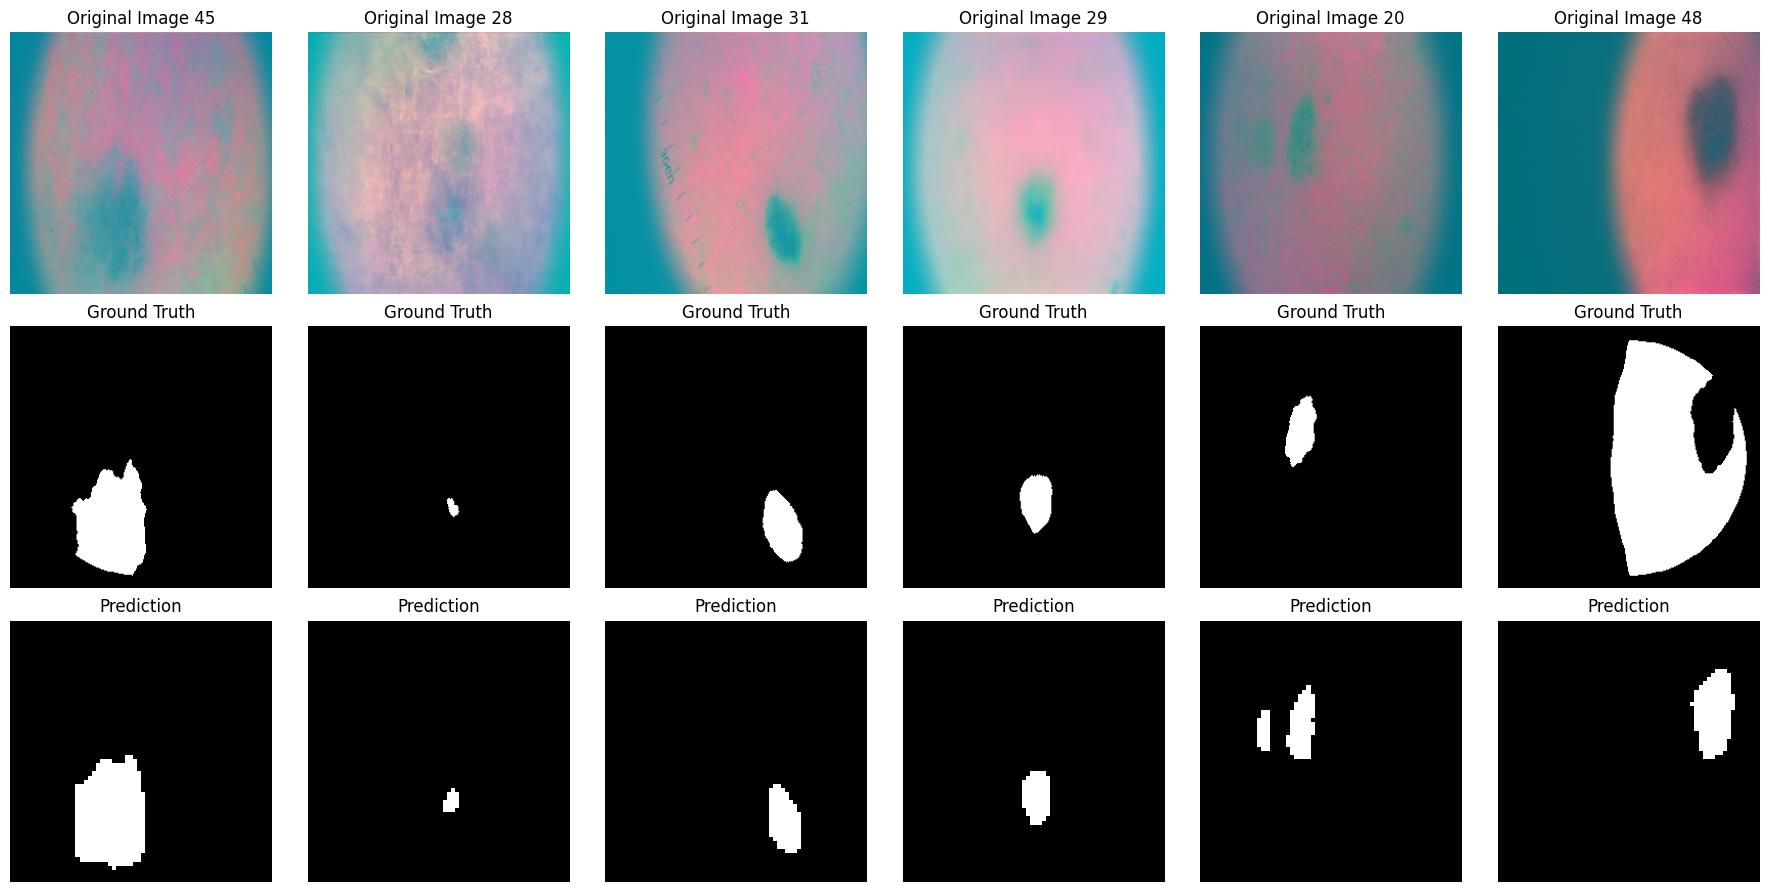

Sample 0:
  Image shape: torch.Size([3, 256, 256])
  True mask shape: (256, 256)
  Predicted mask shape: (64, 64)
  Resizing predicted_mask from (64, 64) to (256, 256)
Sample 1:
  Image shape: torch.Size([3, 256, 256])
  True mask shape: (256, 256)
  Predicted mask shape: (64, 64)
  Resizing predicted_mask from (64, 64) to (256, 256)
Sample 2:
  Image shape: torch.Size([3, 256, 256])
  True mask shape: (256, 256)
  Predicted mask shape: (64, 64)
  Resizing predicted_mask from (64, 64) to (256, 256)
Sample 3:
  Image shape: torch.Size([3, 256, 256])
  True mask shape: (256, 256)
  Predicted mask shape: (64, 64)
  Resizing predicted_mask from (64, 64) to (256, 256)
Overlay visualization saved to Visualizations\overlay_predictions.png


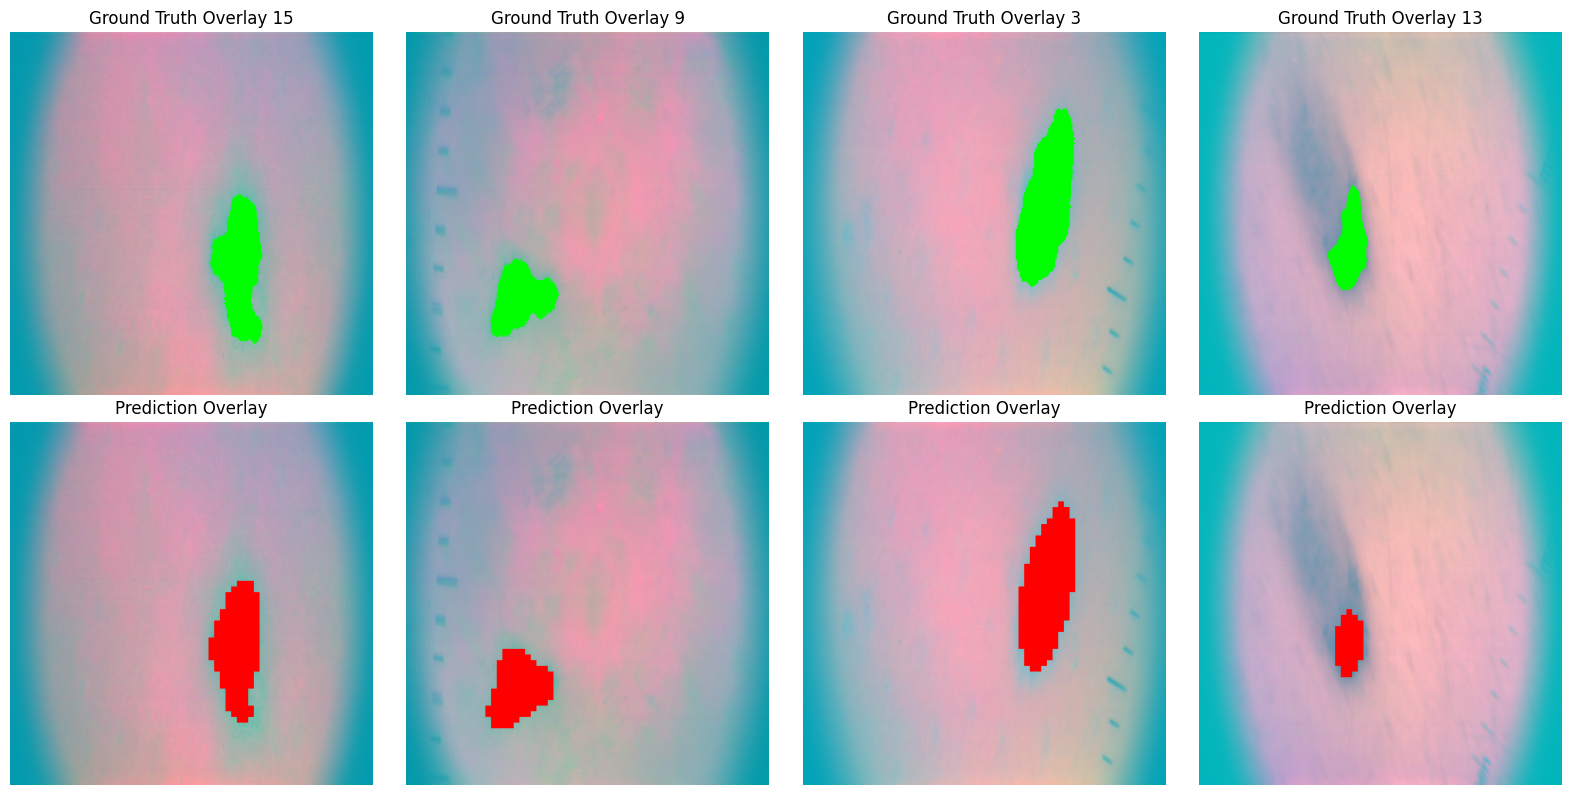


Training completed! Results saved in SegformerResults
Visualizations saved in Visualizations


In [26]:
print("\nPerforming comprehensive evaluation...")

# Evaluate on validation set
val_metrics = evaluate_model_comprehensive(model, val_dataset, device)

print("\nFinal Validation Metrics:")
print("=" * 40)
for metric, value in val_metrics.items():
    print(f"{metric.replace('_', ' ').title()}: {value:.4f}")

# Create visualizations
print("\nGenerating visualizations...")

# Training metrics plot
plot_training_metrics(trainer, save_path=os.path.join(VISUALIZATION_DIR, 'training_metrics.png'))

# Prediction visualizations
visualize_predictions(model, val_dataset, device, num_samples=6, 
                        save_path=os.path.join(VISUALIZATION_DIR, 'predictions.png'))

visualize_overlay_predictions(model, val_dataset, device, num_samples=4,
                            save_path=os.path.join(VISUALIZATION_DIR, 'overlay_predictions.png'))

# Save metrics to file
with open(os.path.join(RESULTS_DIR, 'final_metrics.txt'), 'w') as f:
    f.write("Final Validation Metrics\n")
    f.write("=" * 30 + "\n")
    for metric, value in val_metrics.items():
        f.write(f"{metric.replace('_', ' ').title()}: {value:.4f}\n")

print(f"\nTraining completed! Results saved in {RESULTS_DIR}")
print(f"Visualizations saved in {VISUALIZATION_DIR}")